In [4]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd


In [5]:
file_path = '/content/drive/MyDrive/FYP/Datasets/machine_learning_balance_CIC-IDS-2017_data.csv'
df = pd.read_csv(file_path)
print(df)

         flow_duration  total_fwd_packets  total_backward_packets  \
0               1001.0                4.0                     0.0   
1          101613739.0                8.0                     5.0   
2             285697.0                2.0                     2.0   
3                196.0                2.0                     2.0   
4              60643.0                1.0                     1.0   
...                ...                ...                     ...   
1113387      1216777.0               19.0                    20.0   
1113388    115728534.0               20.0                    17.0   
1113389          231.0                2.0                     2.0   
1113390      1785987.0                5.0                     0.0   
1113391        84484.0                2.0                     2.0   

          flow_bytes/s  flow_packets/s  packet_length_mean  packet_length_std  \
0             0.000000     3996.003996            0.000000           0.000000   
1        

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
X = df.drop('label', axis=1)
y = df['label']

# Replace infinite and missing values
X = X.replace([float('inf'), -float('inf')], pd.NA)
X = X.fillna(0)


<ipython-input-7-2830e2017ddd>:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X = X.fillna(0)


In [8]:
sampled_indices = X.sample(n=40000, random_state=42).index
X = X.loc[sampled_indices]
y = y.loc[sampled_indices]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [11]:
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale')  # You can try 'linear', 'poly', etc.
svm_model.fit(X_train_scaled, y_train)


SVC()

In [12]:
y_pred = svm_model.predict(X_test_scaled)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9299

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.94      0.93      3931
           1       0.94      0.92      0.93      4069

    accuracy                           0.93      8000
   macro avg       0.93      0.93      0.93      8000
weighted avg       0.93      0.93      0.93      8000


Confusion Matrix:
 [[3713  218]
 [ 343 3726]]


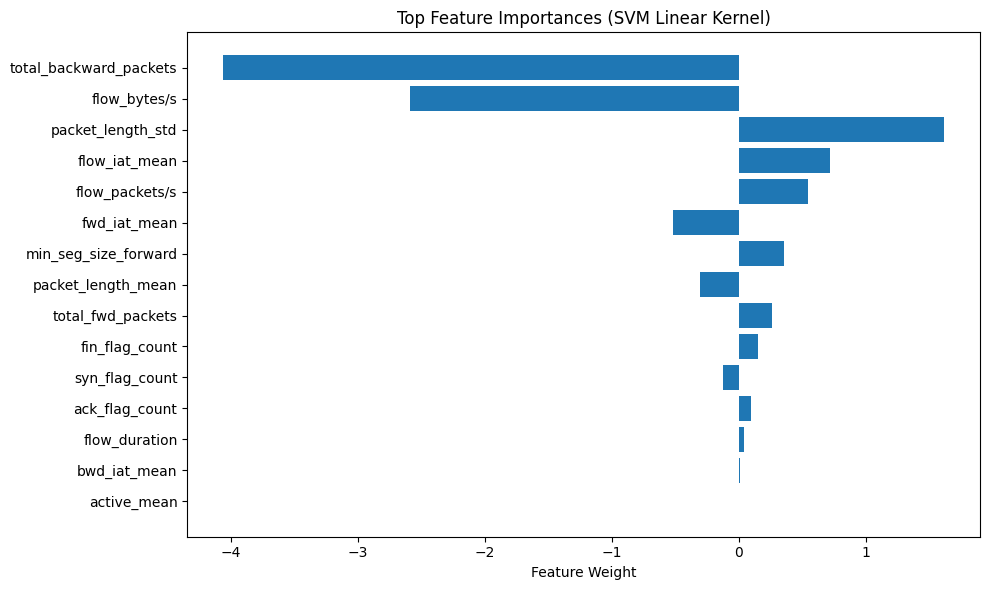

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Use only if you're training with a linear kernel
svm_model = SVC(kernel='linear', C=1.0)
svm_model.fit(X_train_scaled, y_train)

# Get feature weights for binary classification
coefs = svm_model.coef_.ravel()
feature_names = X.columns

# Sort feature indices by absolute importance
indices = np.argsort(np.abs(coefs))[::-1]
top_n = min(20, len(coefs))  # Adjust top_n if fewer features

# Plot
plt.figure(figsize=(10, 6))
plt.barh(range(top_n), coefs[indices[:top_n]][::-1], align='center')
plt.yticks(range(top_n), feature_names[indices[:top_n]][::-1])
plt.xlabel("Feature Weight")
plt.title("Top Feature Importances (SVM Linear Kernel)")
plt.tight_layout()
plt.show()
